In [1]:
# needed libraries

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from pandas.core.common import random_state

## libraries for explanatory regression model..
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [2]:
# sklearn needed for predictive regression model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Lasso,LassoCV,Ridge,RidgeCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [3]:
df=pd.read_csv("/content/winequality-red.csv");

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.shape

(1599, 12)

In [6]:
# check variable types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
# descriptive stats
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Text(0.5, 1.0, 'Heap Map to check null values')

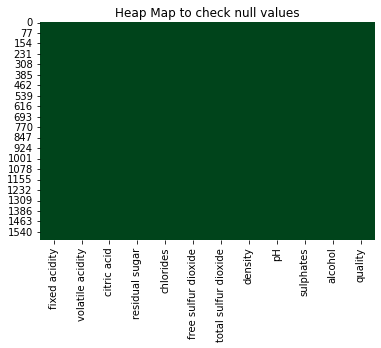

In [8]:
# check for null values
p=sns.heatmap(df.isnull(),cbar=False,cmap='Greens_r')
p.set_title("Heap Map to check null values")

In [9]:
# count null from each column
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**Exploratory Data Analysis**

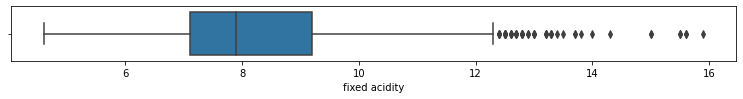

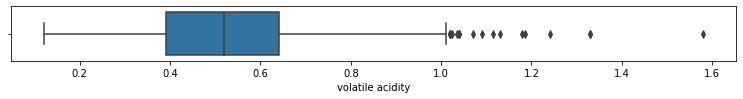

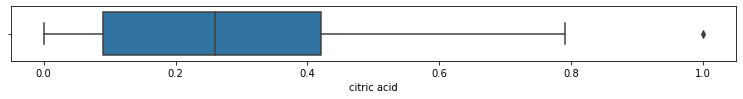

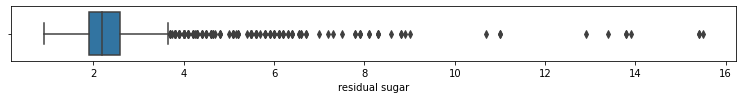

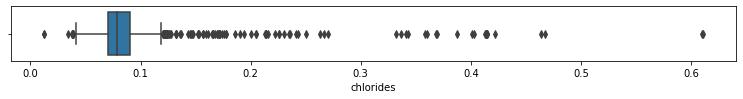

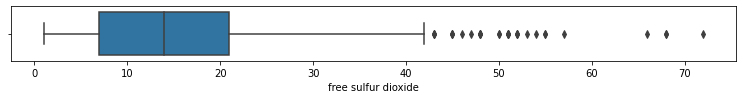

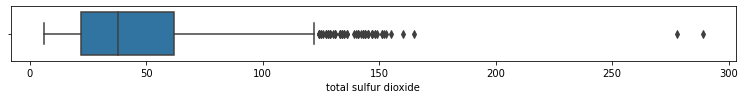

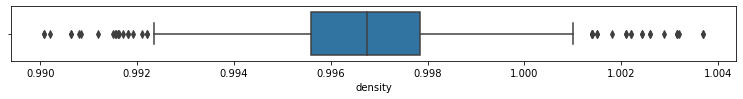

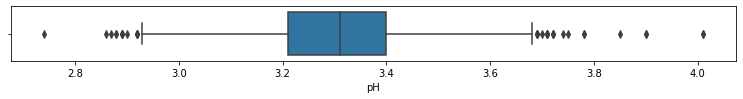

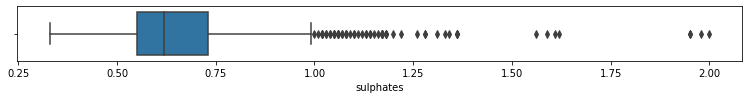

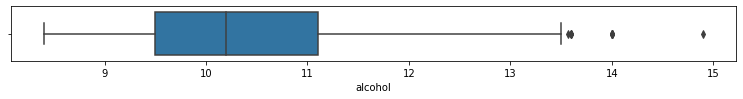

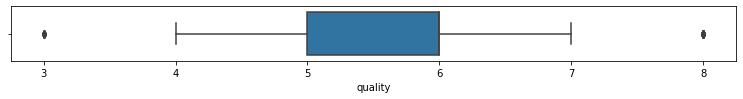

In [10]:
# check for outliers using boxplot
for column in df:
    plt.figure(figsize=(13,1))
    sns.boxplot(x=column,data=df)

Here one can see that the all the features has outliers so inorder to get correct accuracy we need to transform the data 
1. Normalization just bound the data
2. standardization helps in shrinking of the outliers.
after the Transforming of the also one can see that there are outliers..we need to remove based on their importance..

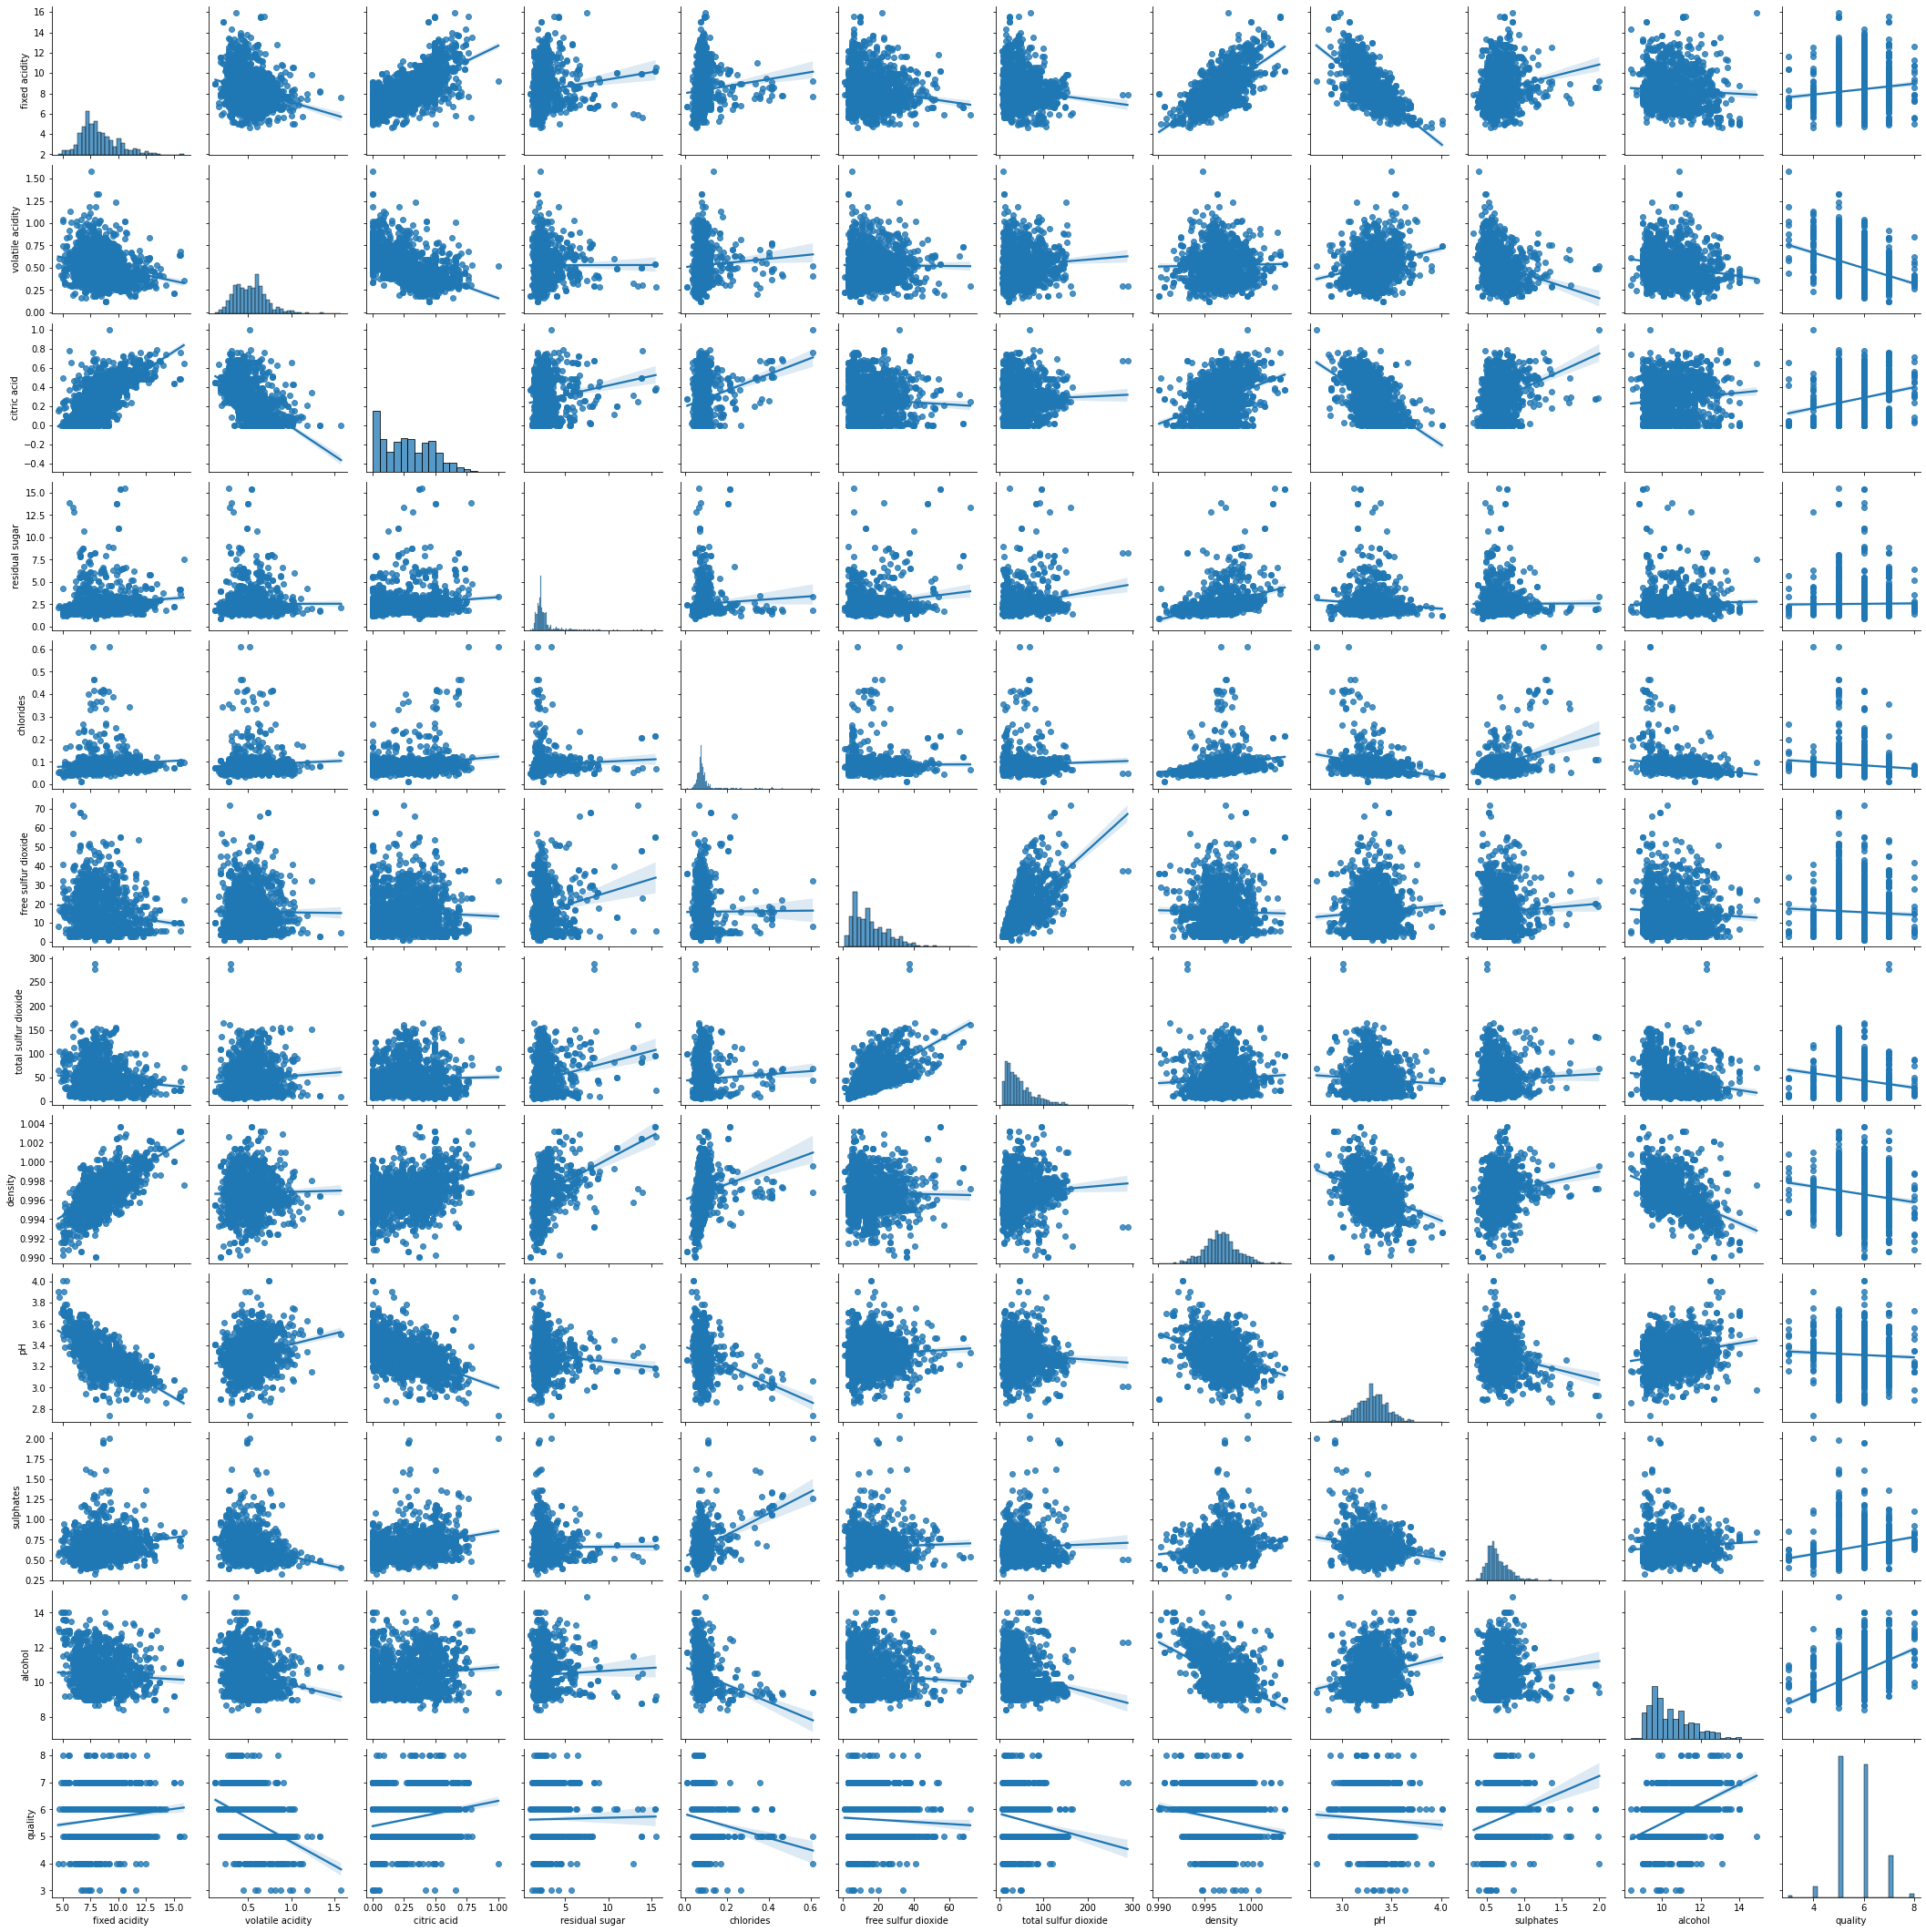

In [11]:
## check for relation b/w each and every attribute
sns.pairplot(df,kind='reg')

Quality Seems like an discerete variable in a certain range [3,8].
Here we can take it as a dependent variable and all other attributes as independent variables.

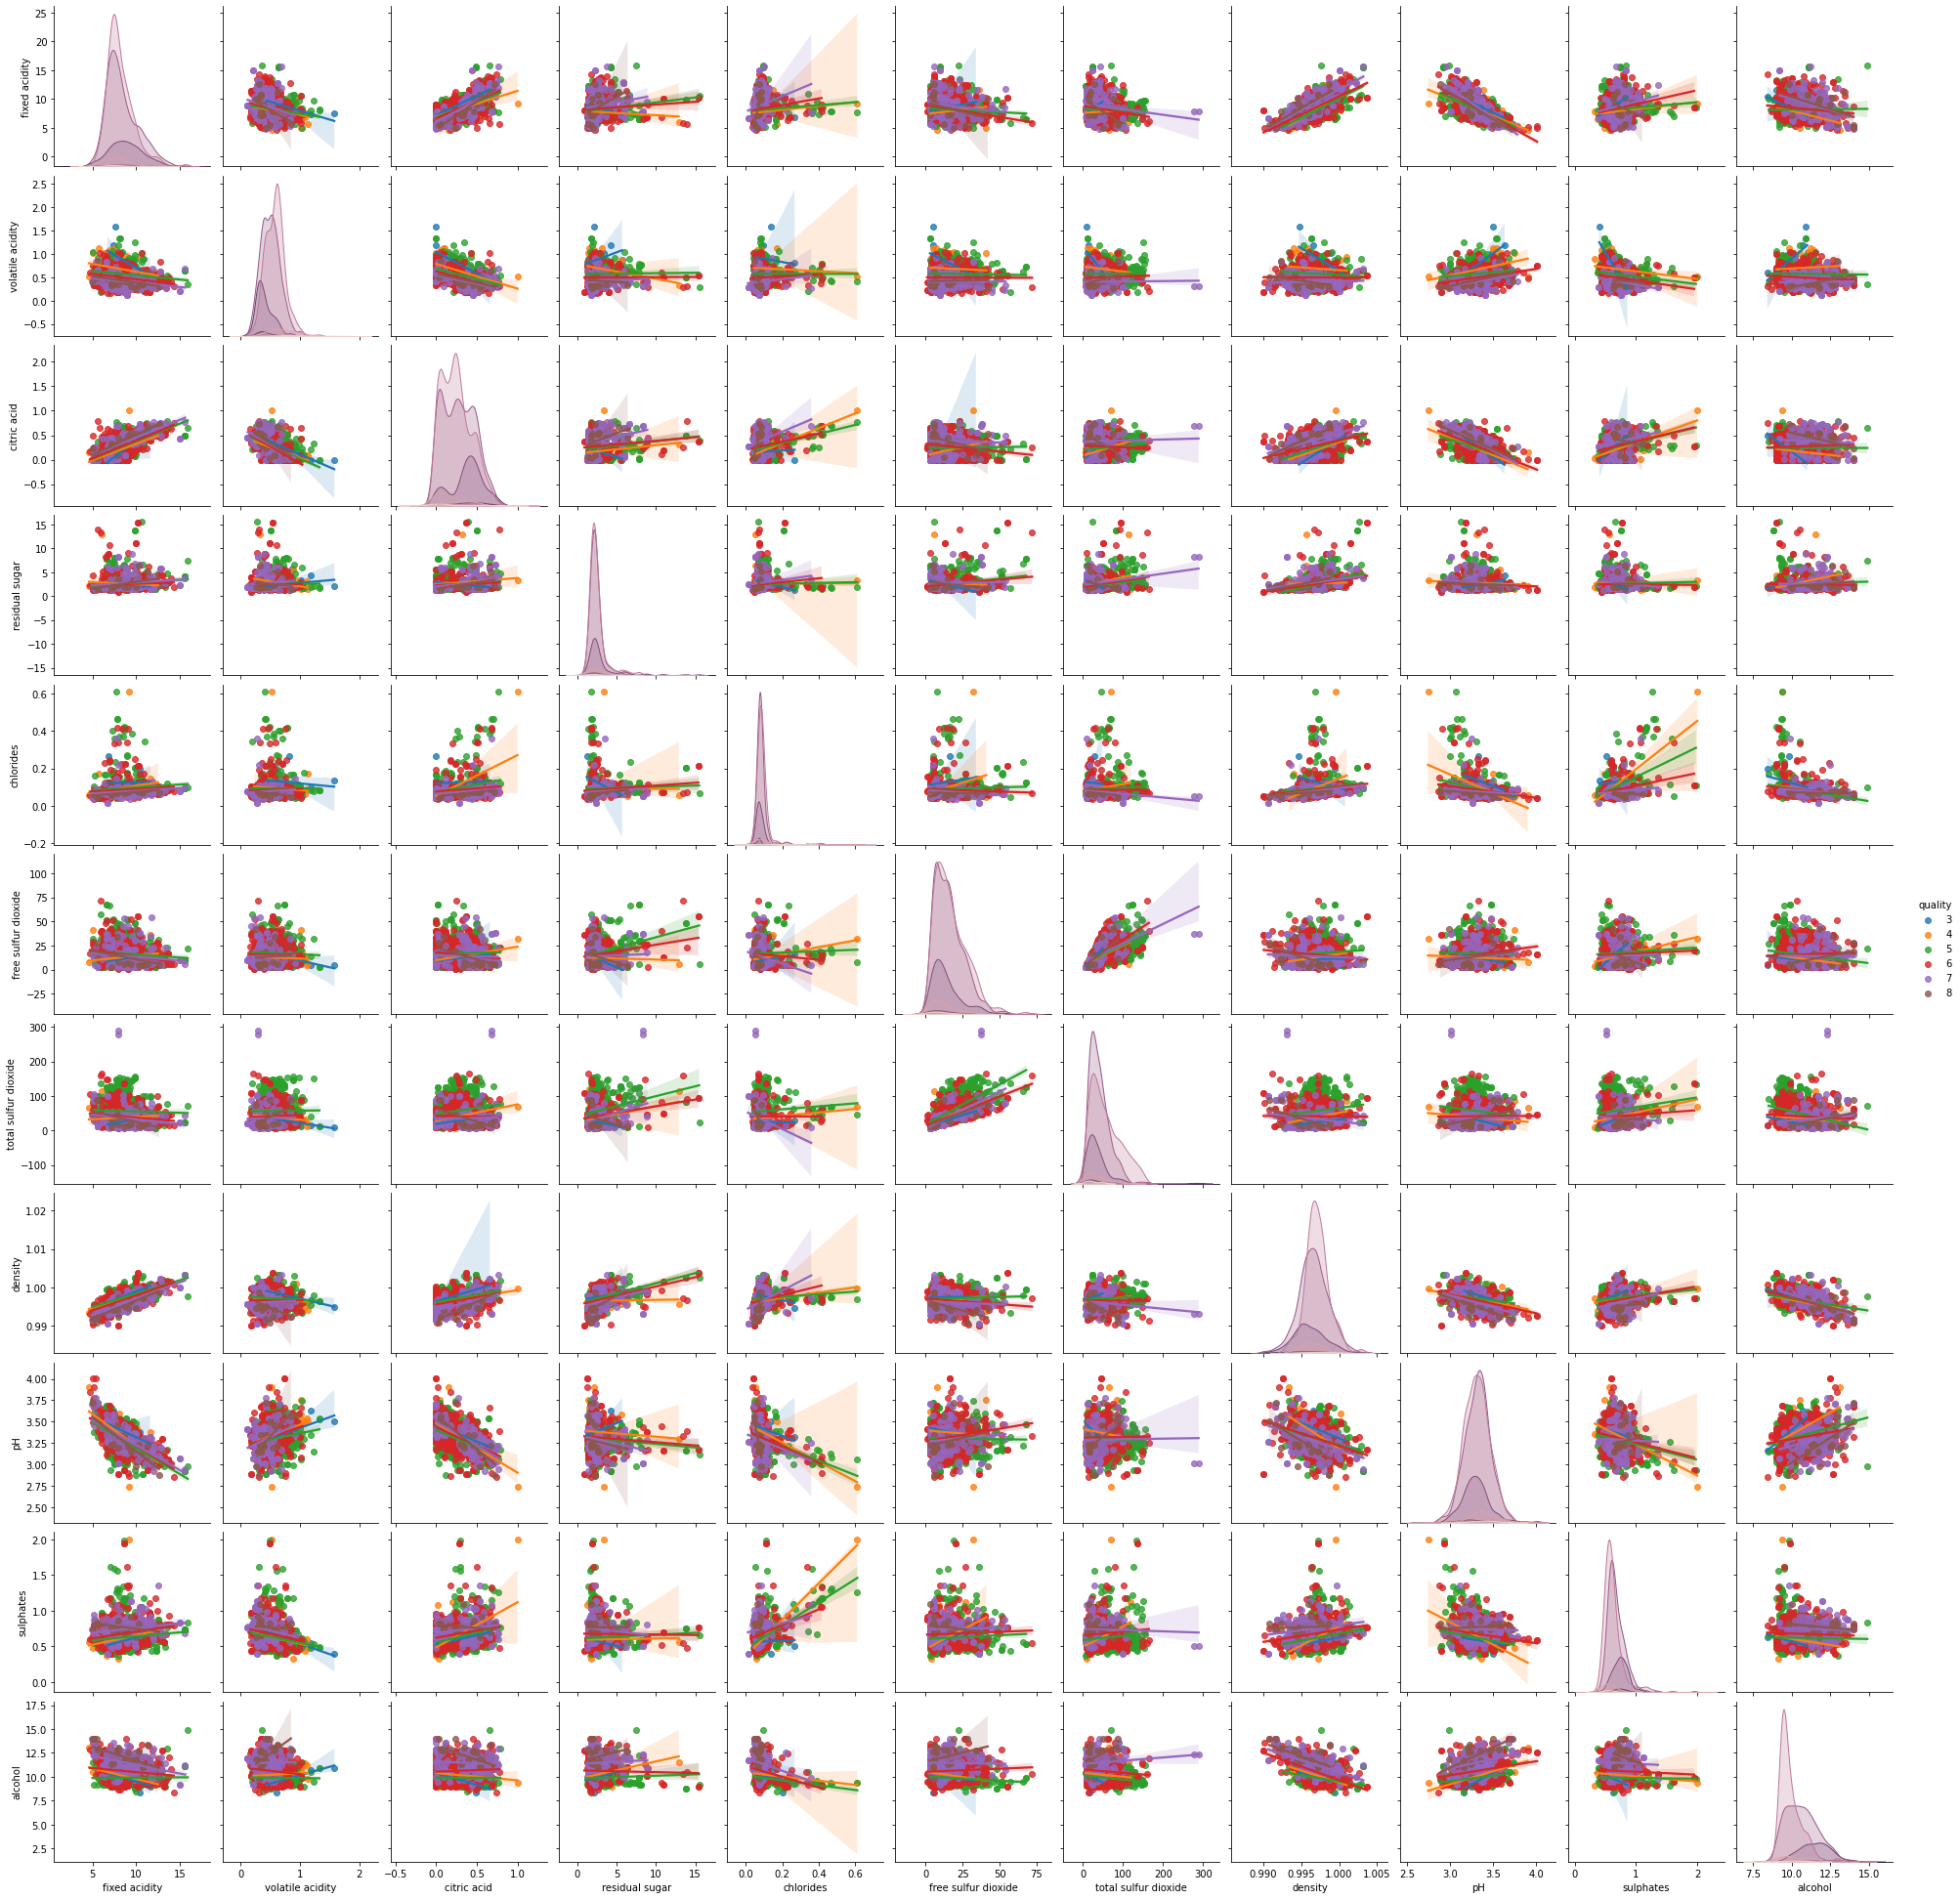

In [12]:
sns.pairplot(df,hue='quality',kind='reg')

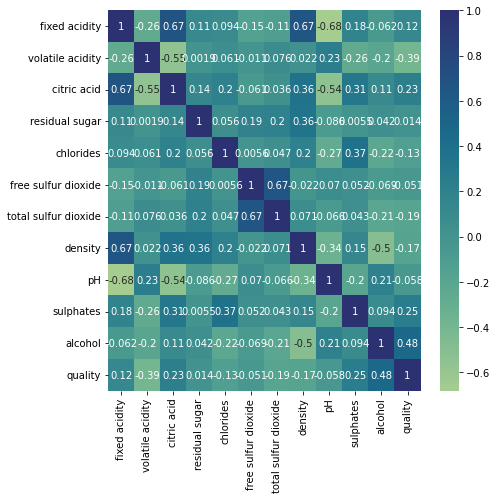

In [13]:
## correlation  a statistical measure that indicates the extent to which two or more 
##                                   variables fluctuate in relation to each other
plt.figure(figsize=(7, 7))
sns.heatmap(df.corr(),cmap="crest",annot=True)

**Data Preprocessing**


1.  Standardize the data 
2.  Data is alerady cleaned


In [14]:
scaler=StandardScaler()
x=df.iloc[:,:-1]
y=df['quality']
X=scaler.fit_transform(x)

In [100]:
# train_test_split
x_train,x_text,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=1)

In [91]:
type(x_train)

numpy.ndarray

In [101]:
## for a model we need to pass numpy arrays only
y_train=y_train.to_numpy()
y_test=y_test.to_numpy()


In [102]:
y_train,y_test

(array([5, 4, 5, ..., 6, 6, 8]),
 array([5, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 6, 6, 6, 5, 6, 5, 5, 5, 6, 6,
        5, 6, 6, 6, 6, 6, 6, 7, 6, 6, 5, 6, 5, 6, 5, 7, 6, 5, 6, 5, 5, 6,
        5, 6, 5, 5, 5, 6, 5, 4, 7, 5, 5, 6, 6, 6, 5, 5, 5, 6, 5, 6, 5, 6,
        7, 6, 6, 6, 5, 6, 6, 6, 5, 5, 6, 6, 5, 6, 5, 5, 5, 6, 5, 5, 5, 7,
        5, 6, 5, 7, 5, 6, 5, 5, 6, 5, 3, 6, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6,
        7, 5, 6, 6, 5, 7, 5, 5, 5, 5, 4, 7, 7, 5, 5, 5, 6, 5, 7, 7, 6, 5,
        7, 5, 6, 7, 5, 7, 6, 6, 5, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6,
        5, 7, 5, 6, 6, 6, 8, 6, 5, 5, 6, 6, 4, 5, 5, 6, 6, 6, 4, 7, 5, 6,
        5, 5, 5, 5, 6, 6, 5, 6, 6, 6, 7, 6, 4, 6, 5, 6, 6, 5, 6, 5, 4, 5,
        6, 5, 7, 5, 7, 5, 7, 6, 5, 5, 6, 5, 5, 7, 5, 6, 5, 6, 5, 5, 7, 6,
        5, 6, 5, 5, 6, 5, 4, 7, 7, 7, 6, 6, 7, 6, 6, 6, 6, 6, 5, 4, 6, 5,
        7, 6, 6, 8, 6, 5, 5, 5, 5, 4, 6, 6, 6, 5, 5, 4, 5, 5, 6, 5, 5, 5,
        4, 6, 5, 5, 6, 6, 5, 6, 5, 6, 6, 5, 5, 6, 5, 5, 6, 4, 4, 5, 6, 5,
     

**Model Selection and Evaluation**

In [103]:
## ordinary least squares model using stats models api
ols=sm.OLS(y_train,sm.add_constant(x_train))
ols.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     61.66
Date:                Sun, 23 Oct 2022   Prob (F-statistic):          2.01e-108
Time:                        14:14:39   Log-Likelihood:                -1192.3
No. Observations:                1199   AIC:                             2409.
Df Residuals:                    1187   BIC:                             2470.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6446      0.019    297.035      0.000       5.607       5.682
x1             0.0726      0.053      1.379      0.168      -0.031       0.176
x2            -0.2088      0.025     -8.322      0.000      -0.258      -0.160
x3            -0.0500      0.033     -1.509      0.132      -0.115       0.015
x4             0.0253      0.026      0.971      0.332      -0.026       0.077
x5            -0.0841      0.023     -3.598      0.000      -0.130      -0.038
x6             0.0515      0.027      1.900      0.058      -0.002       0.105
x7            -0.1168      0.029     -4.079      0.000      -0.173      -0.061
x8            -0.0669      0.048     -1.401      0.161      -0.161       0.027
x9            -0.0594      0.034     -1.736      0.083      -0.127       0.008
x10            0.1497      0.023      6.587      0.000       0.105       0.194
x11            0.2811      0.033      8.527      0.000       0.216       0.346
==============================================================================
Omnibus:                       20.748   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.299
Skew:                          -0.171   Prob(JB):                     2.63e-07
Kurtosis:                       3.700   Cond. No.                         7.37
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Model coefficients [ 0.07259391 -0.20884172 -0.04995238  0.02534502 -0.08411056  0.05153578
 -0.11680133 -0.06689119 -0.05942308  0.14974917  0.28111929]
Model intercepts 5.64455123852577
MSE 0.3865813862375548 RMSE 0.6217566937617598 MAE 0.4801338538605372 r20.3436370198437033


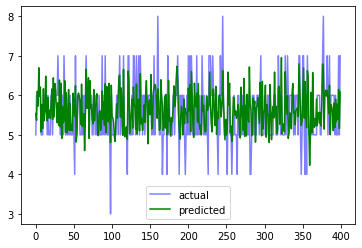

Test Score of the model 0.3436370198437033


In [104]:
## Linear Regression Model
lm=LinearRegression()
model=lm.fit(x_train,y_train)

print("Model coefficients {}".format(model.coef_))
print("Model intercepts {}".format(model.intercept_))

## prediction
predict=model.predict(x_text)
residuals=abs(y_test-predict) ## error values

## evaluation metrics
MSE = mean_squared_error(y_test, predict)
MAE= mean_absolute_error(y_test,predict)
RMSE = mean_squared_error(y_test, predict, squared=False)
r2=r2_score(y_test, predict)
print("MSE {} RMSE {} MAE {} r2{}".format(MSE,RMSE,MAE,r2))

## plot the graph..
plt.plot(y_test,color='b',alpha=0.5)
plt.plot(predict,color='green')
plt.legend(labels=['actual','predicted'],loc='lower center')
plt.show()
print("Test Score of the model",model.score(x_text,y_test))

1.RMSE :A Model with lower value of and nearer to 0 to is the best fit.

---


2.MAE :A model with value nearer to 0 is better fit.

---


3.R2 indicates the variability between the data points.
and this value is more importanat. and if this value nears to 1 then it's a better fitting model

Model coefficients [ 0.05492205 -0.2061359  -0.03945389  0.01735259 -0.08297983  0.0470833
 -0.11263136 -0.05202965 -0.06124538  0.14513033  0.28670842]
Model intercepts 5.644539529617828
MSE 0.3854234949023126 RMSE 0.6208248504226556 MAE 0.4803328941146073 r20.34560296294017123


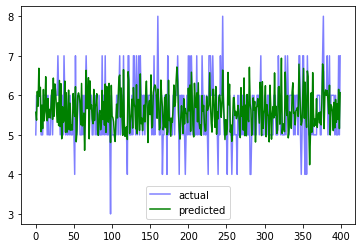

Test Score of the model 0.34560296294017123


In [105]:
## Lasso Regression Model L1 Regularization technique 
## Linear Regression Model
lm=Lasso(alpha=0.002)
model=lm.fit(x_train,y_train)

print("Model coefficients {}".format(model.coef_))
print("Model intercepts {}".format(model.intercept_))

## prediction
predict=model.predict(x_text)
residuals=abs(y_test-predict) ## error values

## evaluation metrics
MSE = mean_squared_error(y_test, predict)
MAE= mean_absolute_error(y_test,predict)
RMSE = mean_squared_error(y_test, predict, squared=False)
r2=r2_score(y_test, predict)
print("MSE {} RMSE {} MAE {} r2{}".format(MSE,RMSE,MAE,r2))

## plot the graph..
plt.plot(y_test,color='b',alpha=0.5)
plt.plot(predict,color='green')
plt.legend(labels=['actual','predicted'],loc='lower center')
plt.show()
print("Test Score of the model",model.score(x_text,y_test))


Model coefficients [ 0.07259378 -0.20883921 -0.04994805  0.02534521 -0.0841104   0.05153441
 -0.11680019 -0.06689329 -0.05942081  0.14974826  0.2811157 ]
Model intercepts 5.644551258529894
MSE 0.3865810924761873 RMSE 0.6217564575267291 MAE 0.4801339214086074 r20.34363751861082836


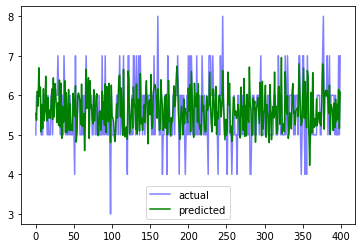

Test Score of the model 0.34363751861082836


In [106]:
## Ridge Regression Model L2 Regularization technique 
lm=Ridge(alpha=0.01)
model=lm.fit(x_train,y_train)

print("Model coefficients {}".format(model.coef_))
print("Model intercepts {}".format(model.intercept_))

## prediction
predict=model.predict(x_text)
residuals=abs(y_test-predict) ## error values

## evaluation metrics
MSE = mean_squared_error(y_test, predict)
MAE= mean_absolute_error(y_test,predict)
RMSE = mean_squared_error(y_test, predict, squared=False)
r2=r2_score(y_test, predict)
print("MSE {} RMSE {} MAE {} r2{}".format(MSE,RMSE,MAE,r2))

## plot the graph..
plt.plot(y_test,color='b',alpha=0.5)
plt.plot(predict,color='green')
plt.legend(labels=['actual','predicted'],loc='lower center')
plt.show()
print("Test Score of the model",model.score(x_text,y_test))


Models after Regualarization also shwoing the same scores and this means we cannot use the linear regression model for this purpose.

Another Reason is that quality has  6 discrete class labels [3 to 8] then try Logistic Regresion.
